Plotting-Funktionen für Top Kanäle, Verteilungen Videos
Analyse der Korrelation Topic -> Sponsor
Validierung und Berechnung der Accuracy der Sponsor-Labels
N-Gram Grafiken

In [159]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

from scipy.stats import chi2_contingency

In [160]:
text_df=pd.read_parquet("/Users/lmeyer/Programmierung DH/Projektarbeit_YT/scripts/sponsors_and_text.parquet")
channel_df=pd.read_parquet("/Users/lmeyer/Programmierung DH/Projektarbeit_YT/converted_dataset/channel_data_0000.parquet")

# Top 20 Kanäle

In [161]:
text_df.head()

,video_id,sponsor,sponsor_ents,raw_entities,known_entities,id,channel_id,channel_title,title,description,published_at,view_count,default_language,topic_categories,subtitles,snippet,statistics,sponsor_text,combined_text
0,9nP0ot-gnso,dashlane,"[dashlane, dashlane, reddit]","[Dashlane, Dashlane, Reddit, Epidemic Sound]",None,9nP0ot-gnso,UCuCkxoKLYO_EQ2GeFtbM_bw,Half as Interesting,The Accidental Virtual Pandemic in World of Wa...,Start browning more easily and safely by signi...,2020-03-26T15:03:18Z,1253712,en,"[https://en.wikipedia.org/wiki/Action_game, ht...","[{'duration_ms': 2399.0, 'start_ms': 480, 'tex...","{'categoryId': '27', 'channelId': 'UCuCkxoKLYO...","{'commentCount': '1614', 'favoriteCount': '0',...",This video was made possible by Dashlane. Prot...,This video was made possible by Dashlane. Prot...
1,9nP_cZEWVbA,notion,"[notion, artificialmusic, lukrembo, notion]","[Notion, Not, Artificial Music, Lukrembo, Notion]",None,9nP_cZEWVbA,UCsm-uFE1pEJnmySSCRTStaA,Thoughtworthy Co,A Day in Our Life: Working Together as Introve...,"A boring, chaotic day in the life of a couple ...",2022-08-06T12:00:05Z,20987,en,[https://en.wikipedia.org/wiki/Lifestyle_(soci...,"[{'duration_ms': 3280.0, 'start_ms': 17200, 't...","{'categoryId': '22', 'channelId': 'UCsm-uFE1pE...","{'commentCount': '120', 'favoriteCount': '0', ...","By the way, this video is sponsored by Notion,...","By the way, this video is sponsored by Notion,..."
2,9nV8UxyAO8I,surfshark,"[surfshark, Surfshark, surfshark]",[Surfshark],"[Surfshark, surfshark]",9nV8UxyAO8I,UCKipICKHTWUR9nmkGFUiFgg,Looking 4,Why Tokyo's Next Earthquake could be a Disaster,Go to 👉 https://surfshark.com/looking for an e...,2024-10-22T20:16:01Z,6951,en,[https://en.wikipedia.org/wiki/Society],"[{'duration_ms': 3840.0, 'start_ms': 2720, 'te...","{'categoryId': '25', 'channelId': 'UCKipICKHTW...","{'commentCount': '6', 'favoriteCount': '0', 'l...",So it's best to be well prepared. Speaking of ...,So it's best to be well prepared. Speaking of ...
3,9napKYGvzhE,saviorheat,"[saviorheat, saviorheat, saviorheat]","[Savior Heat, Savior Heat, Savior Heat]",None,9napKYGvzhE,UC5xVi5G_-ooVCoGyttV4K2w,SRG Skiing,An Insider’s Guide to Sunshine Village (Part a...,Thanks to Savior Heat for sponsoring! Check th...,2024-10-05T00:00:18Z,3863,en,[https://en.wikipedia.org/wiki/Lifestyle_(soci...,"[{'duration_ms': 4720.0, 'start_ms': 720, 'tex...","{'categoryId': '19', 'channelId': 'UC5xVi5G_-o...","{'commentCount': '12', 'favoriteCount': '0', '...","Resorts: Sunshine Village. [Intro] Now, we’re ...","Resorts: Sunshine Village. [Intro] Now, we’re ..."
4,9ndXUcnFPyU,extensionschool,"[harvardextensionschool, extensionschool, exte...","[Harvard Extension School, Extension School, E...",None,9ndXUcnFPyU,UC3KNWfcAsfHDqIzHExknhFQ,Harvard Extension School,Welcome to HES: Getting Started Information Se...,Watch this recording of our first information ...,2023-07-03T13:59:09Z,2295,en,[https://en.wikipedia.org/wiki/Knowledge],"[{'duration_ms': 1420.0, 'start_ms': 31780, 't...","{'categoryId': '27', 'channelId': 'UC3KNWfcAsf...","{'commentCount': '7', 'favoriteCount': '0', 'l...",Good afternoon. Thank you for joining us today...,Good afternoon. Thank you for joining us today...


In [162]:
channel_df.head()

,id,channel_title,channel_description,channel_handle,channel_country,channel_topic_ids,channel_topic_categories,channel_snippet,channel_statistics
0,UCQs6Vkvy2h6vMcz4amPWUhA,Instagrafia,Hey in this channel we bring you the latest fa...,@instagrafia,IN,"[/m/032tl, /m/019_rr]","[https://en.wikipedia.org/wiki/Fashion, https:...","{'country': 'IN', 'customUrl': '@instagrafia',...","{'hiddenSubscriberCount': False, 'subscriberCo..."
1,UCVI-gmqb3PhWwecTigx8P7Q,Rina Sawayama,💥Official YouTube channel of Rina Sawayama💥 \n...,@rinasawayamaofficial,GB,"[/m/04rlf, /m/064t9, /m/02jjt, /m/02lkt, /m/02...","[https://en.wikipedia.org/wiki/Music, https://...","{'country': 'GB', 'customUrl': '@rinasawayamao...","{'hiddenSubscriberCount': False, 'subscriberCo..."
2,UCla3r8QMYO9uT9lN55ZOQNQ,Rad Dad's Print Lab,Just a Dad who enjoys 3d printing and making s...,@raddadsprintlab,US,"[/m/03glg, /m/019_rr, /m/07c1v]","[https://en.wikipedia.org/wiki/Hobby, https://...","{'country': 'US', 'customUrl': '@raddadsprintl...","{'hiddenSubscriberCount': False, 'subscriberCo..."
3,UCvOU-zTlankT-JjN3ZzvuKA,Podcastage,Podcastage is a youtube channel that provides ...,@podcastage,US,"[/m/07c1v, /m/019_rr]","[https://en.wikipedia.org/wiki/Technology, htt...","{'country': 'US', 'customUrl': '@podcastage', ...","{'hiddenSubscriberCount': False, 'subscriberCo..."
4,UCNsNMUpPrKOtd6DBPtwNa9w,The World Of Science,We Make People Fall In Love With Space & Scien...,@theworldofscienceco,IN,[/m/01k8wb],[https://en.wikipedia.org/wiki/Knowledge],"{'country': 'IN', 'customUrl': '@theworldofsci...","{'hiddenSubscriberCount': False, 'subscriberCo..."


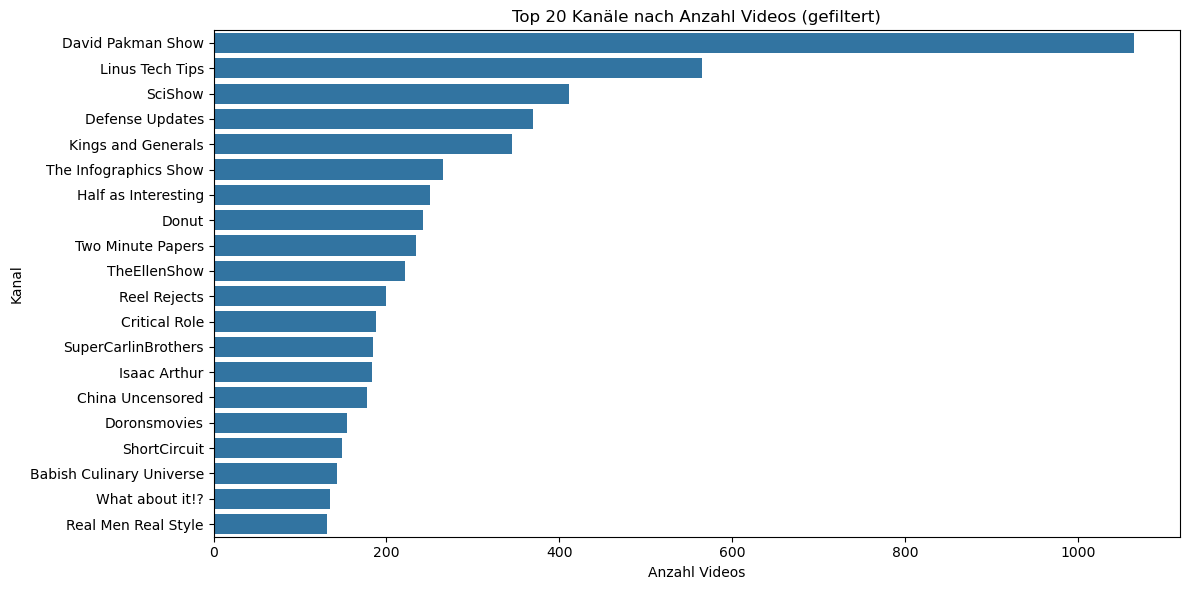

In [163]:
top_20 = text_df["channel_title"].value_counts().nlargest(20).index
filtered_df = text_df[text_df["channel_title"].isin(top_20)]
plt.figure(figsize=(12, 6))
sns.countplot(data=filtered_df, y="channel_title", order=top_20)
plt.title("Top 20 Kanäle nach Anzahl Videos (gefiltert)")
plt.xlabel("Anzahl Videos")
plt.ylabel("Kanal")
plt.tight_layout()
plt.show()

# Videos nach Jahren

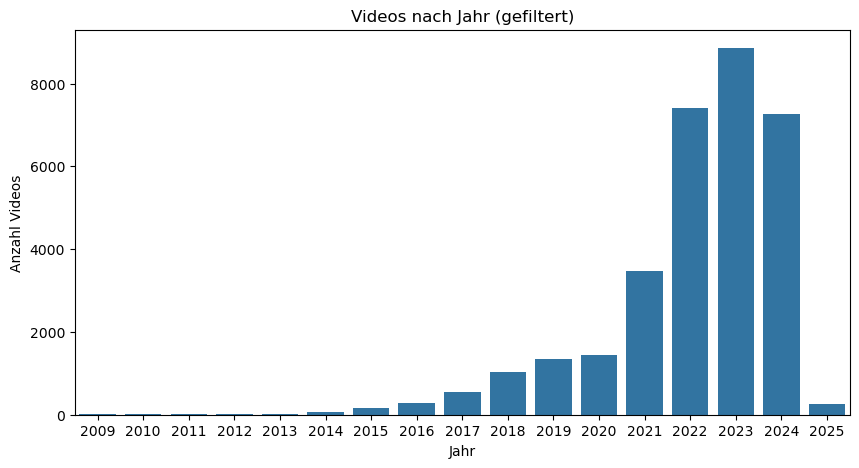

In [164]:
text_df['published_at'] = pd.to_datetime(text_df['published_at'], utc=True)
text_df['year'] = text_df['published_at'].dt.year
year_counts = text_df['year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=year_counts.index, y=year_counts.values)
plt.xlabel('Jahr')
plt.ylabel('Anzahl Videos')
plt.title('Videos nach Jahr (gefiltert)')
plt.show()

# Histogram Video-Views

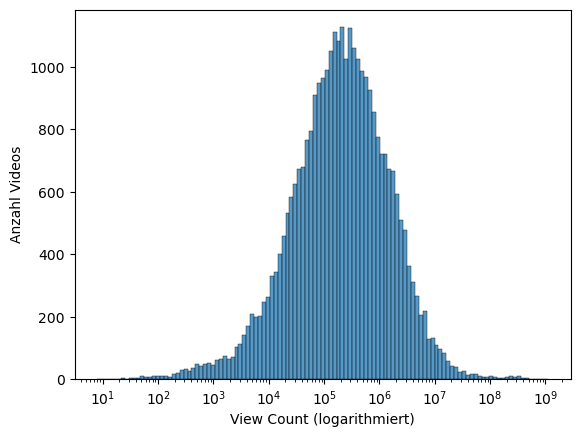

In [165]:
text_df["view_count"] = pd.to_numeric(text_df["view_count"], errors="coerce")

sns.histplot(text_df["view_count"], log_scale=(True, False))
plt.xlabel("View Count (logarithmiert)")
plt.ylabel("Anzahl Videos")
plt.show()

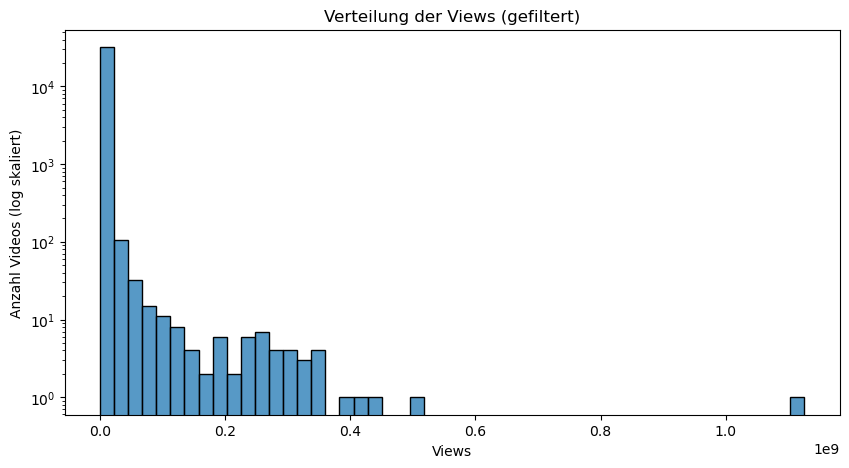

In [166]:
plt.figure(figsize=(10, 5))

ax = sns.histplot(text_df["view_count"], bins=50)
ax.set_yscale("log")

plt.xlabel("Views")
plt.ylabel("Anzahl Videos (log skaliert)")
plt.title('Verteilung der Views (gefiltert)')
plt.show()

# Korrelationen

In [167]:
text_df.head()

,video_id,sponsor,sponsor_ents,raw_entities,known_entities,id,channel_id,channel_title,title,description,published_at,view_count,default_language,topic_categories,subtitles,snippet,statistics,sponsor_text,combined_text,year
0,9nP0ot-gnso,dashlane,"[dashlane, dashlane, reddit]","[Dashlane, Dashlane, Reddit, Epidemic Sound]",None,9nP0ot-gnso,UCuCkxoKLYO_EQ2GeFtbM_bw,Half as Interesting,The Accidental Virtual Pandemic in World of Wa...,Start browning more easily and safely by signi...,2020-03-26 15:03:18+00:00,1253712.0,en,"[https://en.wikipedia.org/wiki/Action_game, ht...","[{'duration_ms': 2399.0, 'start_ms': 480, 'tex...","{'categoryId': '27', 'channelId': 'UCuCkxoKLYO...","{'commentCount': '1614', 'favoriteCount': '0',...",This video was made possible by Dashlane. Prot...,This video was made possible by Dashlane. Prot...,2020
1,9nP_cZEWVbA,notion,"[notion, artificialmusic, lukrembo, notion]","[Notion, Not, Artificial Music, Lukrembo, Notion]",None,9nP_cZEWVbA,UCsm-uFE1pEJnmySSCRTStaA,Thoughtworthy Co,A Day in Our Life: Working Together as Introve...,"A boring, chaotic day in the life of a couple ...",2022-08-06 12:00:05+00:00,20987.0,en,[https://en.wikipedia.org/wiki/Lifestyle_(soci...,"[{'duration_ms': 3280.0, 'start_ms': 17200, 't...","{'categoryId': '22', 'channelId': 'UCsm-uFE1pE...","{'commentCount': '120', 'favoriteCount': '0', ...","By the way, this video is sponsored by Notion,...","By the way, this video is sponsored by Notion,...",2022
2,9nV8UxyAO8I,surfshark,"[surfshark, Surfshark, surfshark]",[Surfshark],"[Surfshark, surfshark]",9nV8UxyAO8I,UCKipICKHTWUR9nmkGFUiFgg,Looking 4,Why Tokyo's Next Earthquake could be a Disaster,Go to 👉 https://surfshark.com/looking for an e...,2024-10-22 20:16:01+00:00,6951.0,en,[https://en.wikipedia.org/wiki/Society],"[{'duration_ms': 3840.0, 'start_ms': 2720, 'te...","{'categoryId': '25', 'channelId': 'UCKipICKHTW...","{'commentCount': '6', 'favoriteCount': '0', 'l...",So it's best to be well prepared. Speaking of ...,So it's best to be well prepared. Speaking of ...,2024
3,9napKYGvzhE,saviorheat,"[saviorheat, saviorheat, saviorheat]","[Savior Heat, Savior Heat, Savior Heat]",None,9napKYGvzhE,UC5xVi5G_-ooVCoGyttV4K2w,SRG Skiing,An Insider’s Guide to Sunshine Village (Part a...,Thanks to Savior Heat for sponsoring! Check th...,2024-10-05 00:00:18+00:00,3863.0,en,[https://en.wikipedia.org/wiki/Lifestyle_(soci...,"[{'duration_ms': 4720.0, 'start_ms': 720, 'tex...","{'categoryId': '19', 'channelId': 'UC5xVi5G_-o...","{'commentCount': '12', 'favoriteCount': '0', '...","Resorts: Sunshine Village. [Intro] Now, we’re ...","Resorts: Sunshine Village. [Intro] Now, we’re ...",2024
4,9ndXUcnFPyU,extensionschool,"[harvardextensionschool, extensionschool, exte...","[Harvard Extension School, Extension School, E...",None,9ndXUcnFPyU,UC3KNWfcAsfHDqIzHExknhFQ,Harvard Extension School,Welcome to HES: Getting Started Information Se...,Watch this recording of our first information ...,2023-07-03 13:59:09+00:00,2295.0,en,[https://en.wikipedia.org/wiki/Knowledge],"[{'duration_ms': 1420.0, 'start_ms': 31780, 't...","{'categoryId': '27', 'channelId': 'UC3KNWfcAsf...","{'commentCount': '7', 'favoriteCount': '0', 'l...",Good afternoon. Thank you for joining us today...,Good afternoon. Thank you for joining us today...,2023


In [168]:
type(text_df.loc[1, "topic_categories"])

numpy.ndarray

In [169]:
def simplify_topic_array(arr):
    if arr is None:
        return np.array([])
    return np.array([url.split('/wiki/')[-1] for url in arr])

text_df['topic_categories'] = text_df['topic_categories'].apply(simplify_topic_array)

In [170]:
df_exploded = text_df.explode('topic_categories')

In [171]:
df_exploded.shape

(59312, 20)

In [172]:
df_exploded.head()

,video_id,sponsor,sponsor_ents,raw_entities,known_entities,id,channel_id,channel_title,title,description,published_at,view_count,default_language,topic_categories,subtitles,snippet,statistics,sponsor_text,combined_text,year
0,9nP0ot-gnso,dashlane,"[dashlane, dashlane, reddit]","[Dashlane, Dashlane, Reddit, Epidemic Sound]",None,9nP0ot-gnso,UCuCkxoKLYO_EQ2GeFtbM_bw,Half as Interesting,The Accidental Virtual Pandemic in World of Wa...,Start browning more easily and safely by signi...,2020-03-26 15:03:18+00:00,1253712.0,en,Action_game,"[{'duration_ms': 2399.0, 'start_ms': 480, 'tex...","{'categoryId': '27', 'channelId': 'UCuCkxoKLYO...","{'commentCount': '1614', 'favoriteCount': '0',...",This video was made possible by Dashlane. Prot...,This video was made possible by Dashlane. Prot...,2020
0,9nP0ot-gnso,dashlane,"[dashlane, dashlane, reddit]","[Dashlane, Dashlane, Reddit, Epidemic Sound]",None,9nP0ot-gnso,UCuCkxoKLYO_EQ2GeFtbM_bw,Half as Interesting,The Accidental Virtual Pandemic in World of Wa...,Start browning more easily and safely by signi...,2020-03-26 15:03:18+00:00,1253712.0,en,Role-playing_video_game,"[{'duration_ms': 2399.0, 'start_ms': 480, 'tex...","{'categoryId': '27', 'channelId': 'UCuCkxoKLYO...","{'commentCount': '1614', 'favoriteCount': '0',...",This video was made possible by Dashlane. Prot...,This video was made possible by Dashlane. Prot...,2020
0,9nP0ot-gnso,dashlane,"[dashlane, dashlane, reddit]","[Dashlane, Dashlane, Reddit, Epidemic Sound]",None,9nP0ot-gnso,UCuCkxoKLYO_EQ2GeFtbM_bw,Half as Interesting,The Accidental Virtual Pandemic in World of Wa...,Start browning more easily and safely by signi...,2020-03-26 15:03:18+00:00,1253712.0,en,Video_game_culture,"[{'duration_ms': 2399.0, 'start_ms': 480, 'tex...","{'categoryId': '27', 'channelId': 'UCuCkxoKLYO...","{'commentCount': '1614', 'favoriteCount': '0',...",This video was made possible by Dashlane. Prot...,This video was made possible by Dashlane. Prot...,2020
1,9nP_cZEWVbA,notion,"[notion, artificialmusic, lukrembo, notion]","[Notion, Not, Artificial Music, Lukrembo, Notion]",None,9nP_cZEWVbA,UCsm-uFE1pEJnmySSCRTStaA,Thoughtworthy Co,A Day in Our Life: Working Together as Introve...,"A boring, chaotic day in the life of a couple ...",2022-08-06 12:00:05+00:00,20987.0,en,Lifestyle_(sociology),"[{'duration_ms': 3280.0, 'start_ms': 17200, 't...","{'categoryId': '22', 'channelId': 'UCsm-uFE1pE...","{'commentCount': '120', 'favoriteCount': '0', ...","By the way, this video is sponsored by Notion,...","By the way, this video is sponsored by Notion,...",2022
2,9nV8UxyAO8I,surfshark,"[surfshark, Surfshark, surfshark]",[Surfshark],"[Surfshark, surfshark]",9nV8UxyAO8I,UCKipICKHTWUR9nmkGFUiFgg,Looking 4,Why Tokyo's Next Earthquake could be a Disaster,Go to 👉 https://surfshark.com/looking for an e...,2024-10-22 20:16:01+00:00,6951.0,en,Society,"[{'duration_ms': 3840.0, 'start_ms': 2720, 'te...","{'categoryId': '25', 'channelId': 'UCKipICKHTW...","{'commentCount': '6', 'favoriteCount': '0', 'l...",So it's best to be well prepared. Speaking of ...,So it's best to be well prepared. Speaking of ...,2024


In [173]:
contingency_table = pd.crosstab(df_exploded['sponsor'], df_exploded['topic_categories'])
contingency_table.head()

topic_categories,Action-adventure_game,Action_game,American_football,Association_football,Baseball,Basketball,Boxing,Business,Casual_game,Christian_music,...,Soul_music,Sport,Sports_game,Strategy_video_game,Technology,Television_program,Tennis,Tourism,Vehicle,Video_game_culture
sponsor,,,,,,,,,,,,,,,,,,,,,
000hours,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
101stairborne,1,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
106seafoodunderground,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10studio,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
123pendej,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [174]:
# Chi2-Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k, r) - 1)))

cramers_v_value = cramers_v(contingency_table)

print(f"Cramers V: {cramers_v_value:.4f}")
print(f"P-Wert (Chi2-Test): {p:.4f}")
print(f"Chi2-Wert: {chi2:.4f}")
print(f"Freiheitsgrade: {dof:.4f}")


Cramers V: 0.4234
P-Wert (Chi2-Test): 0.0000
Chi2-Wert: 604806.0437
Freiheitsgrade: 378840.0000


In [175]:
observed = contingency_table.values
residuals = (observed - expected) / np.sqrt(expected)

residuals_df = pd.DataFrame(residuals, 
                            index=contingency_table.index, 
                            columns=contingency_table.columns)


In [176]:
residuals_df.head()

topic_categories,Action-adventure_game,Action_game,American_football,Association_football,Baseball,Basketball,Boxing,Business,Casual_game,Christian_music,...,Soul_music,Sport,Sports_game,Strategy_video_game,Technology,Television_program,Tennis,Tourism,Vehicle,Video_game_culture
sponsor,,,,,,,,,,,,,,,,,,,,,
000hours,-0.258403,-0.273322,-0.038654,-0.056897,-0.024592,-0.025998,-0.032119,-0.089863,-0.058439,-0.011929,...,-0.018861,-0.092784,-0.036767,-0.227977,-0.387134,-0.217025,-0.014610,-0.197005,-0.161590,-0.397516
101stairborne,2.371010,2.200542,-0.054664,-0.080464,-0.034778,-0.036767,-0.045423,-0.127085,-0.082645,-0.016870,...,-0.026674,-0.131216,-0.051996,2.779252,-0.547490,-0.306920,-0.020661,-0.278608,-0.228522,-0.562173
106seafoodunderground,-0.258403,-0.273322,-0.038654,-0.056897,-0.024592,-0.025998,-0.032119,-0.089863,-0.058439,-0.011929,...,-0.018861,-0.092784,-0.036767,-0.227977,-0.387134,-0.217025,-0.014610,-0.197005,-0.161590,-0.397516
10studio,-0.258403,-0.273322,-0.038654,-0.056897,-0.024592,-0.025998,-0.032119,-0.089863,-0.058439,-0.011929,...,-0.018861,-0.092784,-0.036767,-0.227977,-0.387134,-0.217025,-0.014610,-0.197005,-0.161590,-0.397516
123pendej,-0.258403,-0.273322,-0.038654,-0.056897,-0.024592,-0.025998,-0.032119,-0.089863,-0.058439,-0.011929,...,-0.018861,-0.092784,-0.036767,-0.227977,-0.387134,-0.217025,-0.014610,-0.197005,-0.161590,-0.397516


In [177]:
sponsors_count= Counter(text_df["sponsor"])
most_common_sponsors=sponsors_count.most_common(30)
most_common_sponsors=set([n for n, c in most_common_sponsors])
most_common_sponsors

{'athleticgreens',
 'audible',
 'aura',
 'betterhelp',
 'brilliant',
 'curiositystream',
 'factor',
 'groundnews',
 'hellofresh',
 'incogni',
 'intel',
 'keeps',
 'linode',
 'manscaped',
 'nebula',
 'newegg',
 'nordvpn',
 'opera',
 'pcbway',
 'raidshadowlegends',
 'raycon',
 'ridge',
 'shopify',
 'skillshare',
 'squarespace',
 'surfshark',
 'teespring',
 'warthunder',
 'webull',
 'worldanvil'}

In [178]:
residuals_long = residuals_df.reset_index().melt(id_vars='sponsor', 
                                                  var_name='topic', 
                                                  value_name='standard_residual')

residuals_long['abs_residual'] = residuals_long['standard_residual'].abs()
residuals_long = residuals_long[residuals_long["sponsor"].isin(most_common_sponsors)]

top_n = 20
top_pairs = residuals_long.sort_values(by='abs_residual', ascending=False).head(top_n)


In [179]:
print(top_pairs[['sponsor', 'topic', 'standard_residual']])


                  sponsor                    topic  standard_residual
165038          brilliant                Knowledge          40.975945
180694            nordvpn                 Military          34.094091
248598         groundnews                 Politics          30.319790
318063         groundnews                  Society          27.503136
248929            incogni                 Politics          26.753083
351115             newegg               Technology          24.031487
351473             pcbway               Technology          23.292238
350037              intel               Technology          22.452459
371507          surfshark                  Tourism          22.061057
182845         warthunder                 Military          21.561813
318394            incogni                  Society          21.432623
137693        squarespace                    Hobby          19.388817
350511             linode               Technology          19.151801
383350  raidshadowle

In [180]:
residuals_long.head()

,sponsor,topic,standard_residual,abs_residual
431,athleticgreens,Action-adventure_game,-3.232506,3.232506
457,audible,Action-adventure_game,-2.377655,2.377655
470,aura,Action-adventure_game,-2.030860,2.030860
647,betterhelp,Action-adventure_game,-4.728712,4.728712
848,brilliant,Action-adventure_game,-3.839691,3.839691


/var/folders/7l/l25182_s0t37_pj4t5j47jyc0000gn/T/ipykernel_44468/1913753816.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


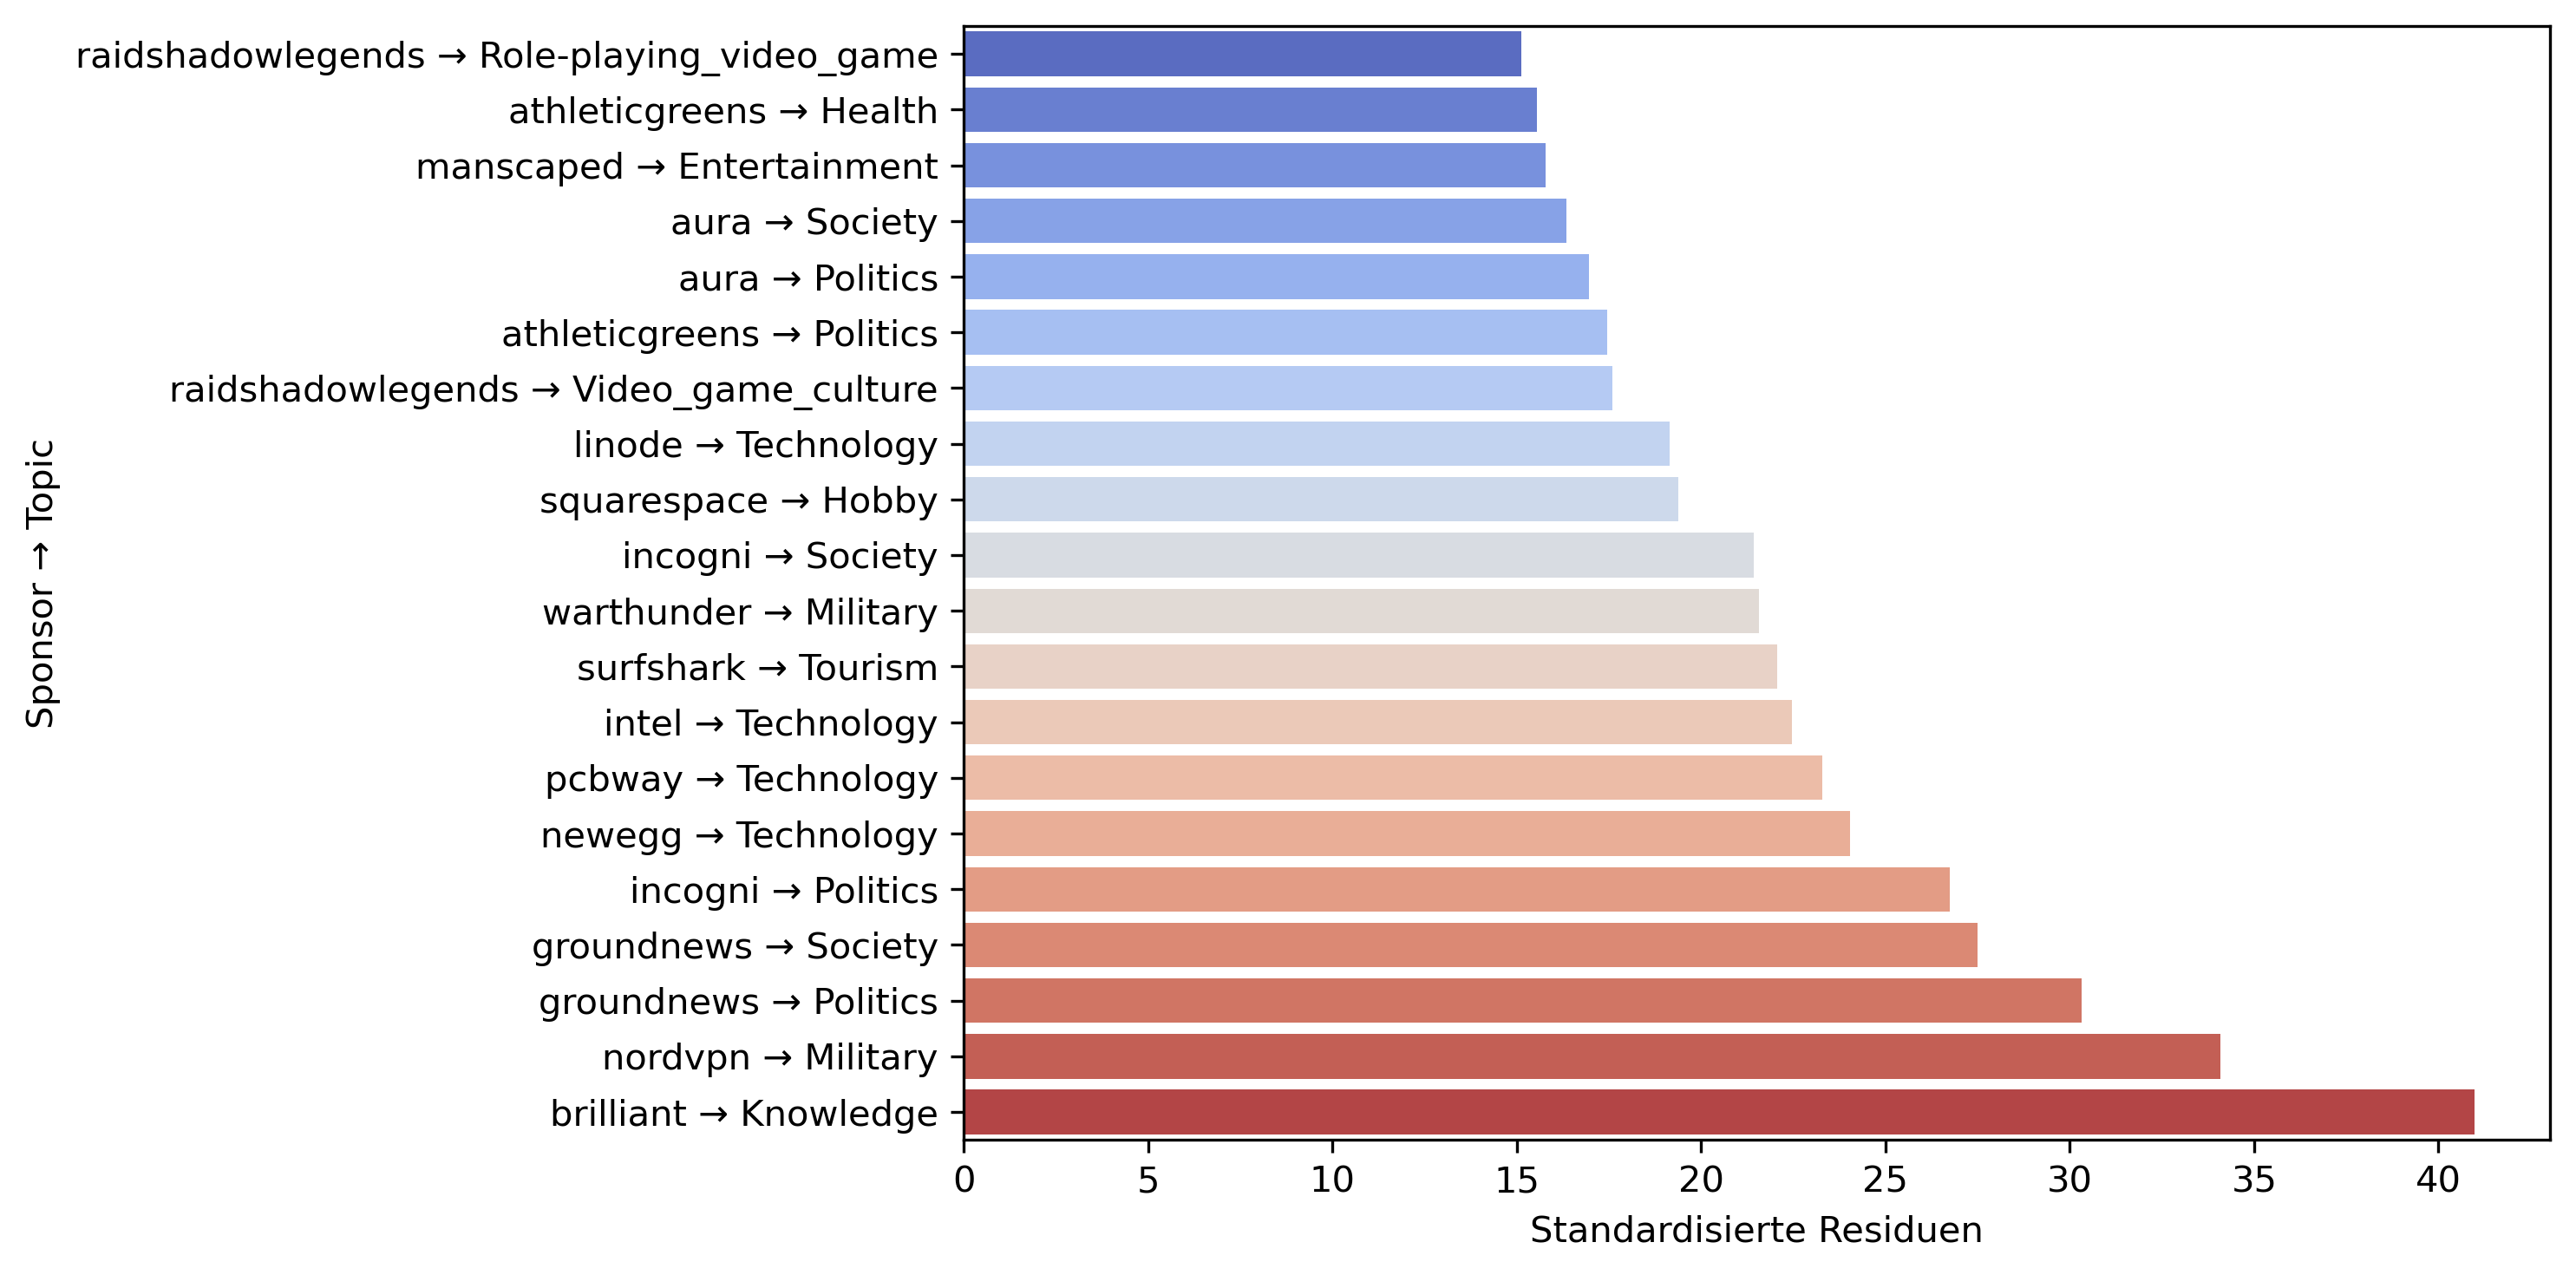

In [181]:
top_pairs = top_pairs.sort_values(by='standard_residual', ascending=True)
plt.figure(figsize=(10, 5), dpi=300)
sns.barplot(
    data=top_pairs,
    x='standard_residual',
    y=top_pairs['sponsor'] + ' → ' + top_pairs['topic'],
    palette='coolwarm'
)
#plt.title('Top signifikanteste Sponsor–Topic-Paare')
plt.xlabel('Standardisierte Residuen')
plt.ylabel('Sponsor → Topic')
plt.tight_layout()
plt.savefig("sponsor_video-topic_korr.png")
plt.show()

# Validierung/Accuracy

In [182]:
v_s_3=pd.read_csv('/Users/lmeyer/Programmierung DH/Projektarbeit_YT/validiation_data/Validation_Sponsors_3 - validation3.csv')

In [183]:
v_s_3

,video_id,link_to_sponsor_1,link_to_sponsor_2,link_to_sponsor_3,sponsor_candidates,sponsor,real_sponsor,in_candidates
0,ZOh08w9Ku9k,http://youtube.com/watch?v=ZOh08w9Ku9k&t=402,NaN,NaN,['squarespace'],squarespace,squarespace,NaN
1,KCLga8tCEMk,http://youtube.com/watch?v=KCLga8tCEMk&t=25,NaN,NaN,"['nordvpn', 'nordvpn', 'nordvpn', 'nordvpn', '...",nordvpn,nordvpn,NaN
2,TDm30r2NkKU,http://youtube.com/watch?v=TDm30r2NkKU&t=501,NaN,NaN,['blackopaldirect'],blackopaldirect,gemfishif1,NaN
3,ToGXv6aheos,http://youtube.com/watch?v=ToGXv6aheos&t=112,NaN,NaN,"['american', 'bent']",american,bespokepost,NaN
4,g_DpVK52P2s,http://youtube.com/watch?v=g_DpVK52P2s&t=53,NaN,NaN,"['magellantv', 'magellantv', 'magellantv', 'ma...",magellantv,magellantv,NaN
...,...,...,...,...,...,...,...,...
145,vTEi5FFxMuE,http://youtube.com/watch?v=vTEi5FFxMuE&t=0,http://youtube.com/watch?v=vTEi5FFxMuE&t=444,NaN,"['brightcellars', 'brightcellars', 'brightcell...",brightcellars,brightcellars,NaN
146,nJ20-C-Q0_A,http://youtube.com/watch?v=nJ20-C-Q0_A&t=57,NaN,NaN,"['aura', 'aura', 'izzard']",aura,aura,NaN
147,tfH1AntrWJU,http://youtube.com/watch?v=tfH1AntrWJU&t=152,NaN,NaN,"['mirror', 'mirror', 'mirror']",mirror,mirror,NaN
148,QEstOkznATY,http://youtube.com/watch?v=QEstOkznATY&t=0,NaN,NaN,"['intuitquickbooks', 'intuitquickbooks', 'intu...",intuitquickbooks,intuitquickbooks,NaN


In [184]:
v_s_3.dropna(axis=0, subset="real_sponsor", inplace=True)

In [185]:
v_s_3

,video_id,link_to_sponsor_1,link_to_sponsor_2,link_to_sponsor_3,sponsor_candidates,sponsor,real_sponsor,in_candidates
0,ZOh08w9Ku9k,http://youtube.com/watch?v=ZOh08w9Ku9k&t=402,NaN,NaN,['squarespace'],squarespace,squarespace,NaN
1,KCLga8tCEMk,http://youtube.com/watch?v=KCLga8tCEMk&t=25,NaN,NaN,"['nordvpn', 'nordvpn', 'nordvpn', 'nordvpn', '...",nordvpn,nordvpn,NaN
2,TDm30r2NkKU,http://youtube.com/watch?v=TDm30r2NkKU&t=501,NaN,NaN,['blackopaldirect'],blackopaldirect,gemfishif1,NaN
3,ToGXv6aheos,http://youtube.com/watch?v=ToGXv6aheos&t=112,NaN,NaN,"['american', 'bent']",american,bespokepost,NaN
4,g_DpVK52P2s,http://youtube.com/watch?v=g_DpVK52P2s&t=53,NaN,NaN,"['magellantv', 'magellantv', 'magellantv', 'ma...",magellantv,magellantv,NaN
...,...,...,...,...,...,...,...,...
145,vTEi5FFxMuE,http://youtube.com/watch?v=vTEi5FFxMuE&t=0,http://youtube.com/watch?v=vTEi5FFxMuE&t=444,NaN,"['brightcellars', 'brightcellars', 'brightcell...",brightcellars,brightcellars,NaN
146,nJ20-C-Q0_A,http://youtube.com/watch?v=nJ20-C-Q0_A&t=57,NaN,NaN,"['aura', 'aura', 'izzard']",aura,aura,NaN
147,tfH1AntrWJU,http://youtube.com/watch?v=tfH1AntrWJU&t=152,NaN,NaN,"['mirror', 'mirror', 'mirror']",mirror,mirror,NaN
148,QEstOkznATY,http://youtube.com/watch?v=QEstOkznATY&t=0,NaN,NaN,"['intuitquickbooks', 'intuitquickbooks', 'intu...",intuitquickbooks,intuitquickbooks,NaN


In [186]:
sum(v_s_3["sponsor"] == v_s_3["real_sponsor"])/len(v_s_3["sponsor"] == v_s_3["real_sponsor"])*100

72.46376811594203

# N-Grams

Nur Plotten der N-Grams
Für Erstellung siehe 'preprocessing_NER_sponsor-ranking_main.py'

In [187]:
ns_3=[(('is', 'sponsored', 'by'), 4634),
 (('this', 'video', 'is'), 4300),
 (('video', 'is', 'sponsored'), 3369),
 (('brought', 'to', 'you'), 2932),
 (('to', 'you', 'by'), 2855),
 (('a', 'lot', 'of'), 2702),
 (('i', 'want', 'to'), 2589),
 (('you', 'want', 'to'), 2490),
 (('in', 'the', 'description'), 2344),
 (('is', 'brought', 'to'), 2299)]


ns_5=[(('this', 'video', 'is', 'sponsored', 'by'), 2612),
 (('is', 'brought', 'to', 'you', 'by'), 2212),
 (('video', 'is', 'brought', 'to', 'you'), 1345),
 (('this', 'video', 'is', 'brought', 'to'), 1040),
 (('the', 'link', 'in', 'the', 'description'), 970),
 (('the', 'sponsor', 'of', 'this', 'video'), 871),
 (('the', 'sponsor', 'of', 'today', 'video'), 784),
 (('this', 'episode', 'is', 'sponsored', 'by'), 699),
 (('in', 'this', 'video', 'defense', 'updates'), 514),
 (('today', 'video', 'is', 'sponsored', 'by'), 510)]

ne_3=[(('in', 'the', 'description'), 9543),
 (('link', 'in', 'the'), 7205),
 (('the', 'link', 'in'), 5589),
 (('for', 'sponsoring', 'this'), 3418),
 (('sponsoring', 'this', 'video'), 2964),
 (('back', 'to', 'the'), 2735),
 (('click', 'the', 'link'), 2300),
 (('this', 'video', 'is'), 2087),
 (('the', 'description', 'below'), 2078),
 (('off', 'your', 'first'), 2074)]


ne_5=[(('the', 'link', 'in', 'the', 'description'), 4440),
 (('click', 'the', 'link', 'in', 'the'), 1524),
 (('link', 'in', 'the', 'description', 'below'), 1319),
 (('this', 'video', 'is', 'sponsored', 'by'), 1189),
 (('is', 'brought', 'to', 'you', 'by'), 952),
 (('link', 'in', 'the', 'description', 'and'), 882),
 (('link', 'in', 'the', 'video', 'description'), 742),
 (('for', 'sponsoring', 'this', 'video', 'and'), 720),
 (('link', 'in', 'the', 'description', 'to'), 708),
 (('purchase', 'of', 'a', 'website', 'or'), 690)]

In [188]:
ngrams= ne_5
total=41277

/var/folders/7l/l25182_s0t37_pj4t5j47jyc0000gn/T/ipykernel_44468/1033372952.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), weight='bold')


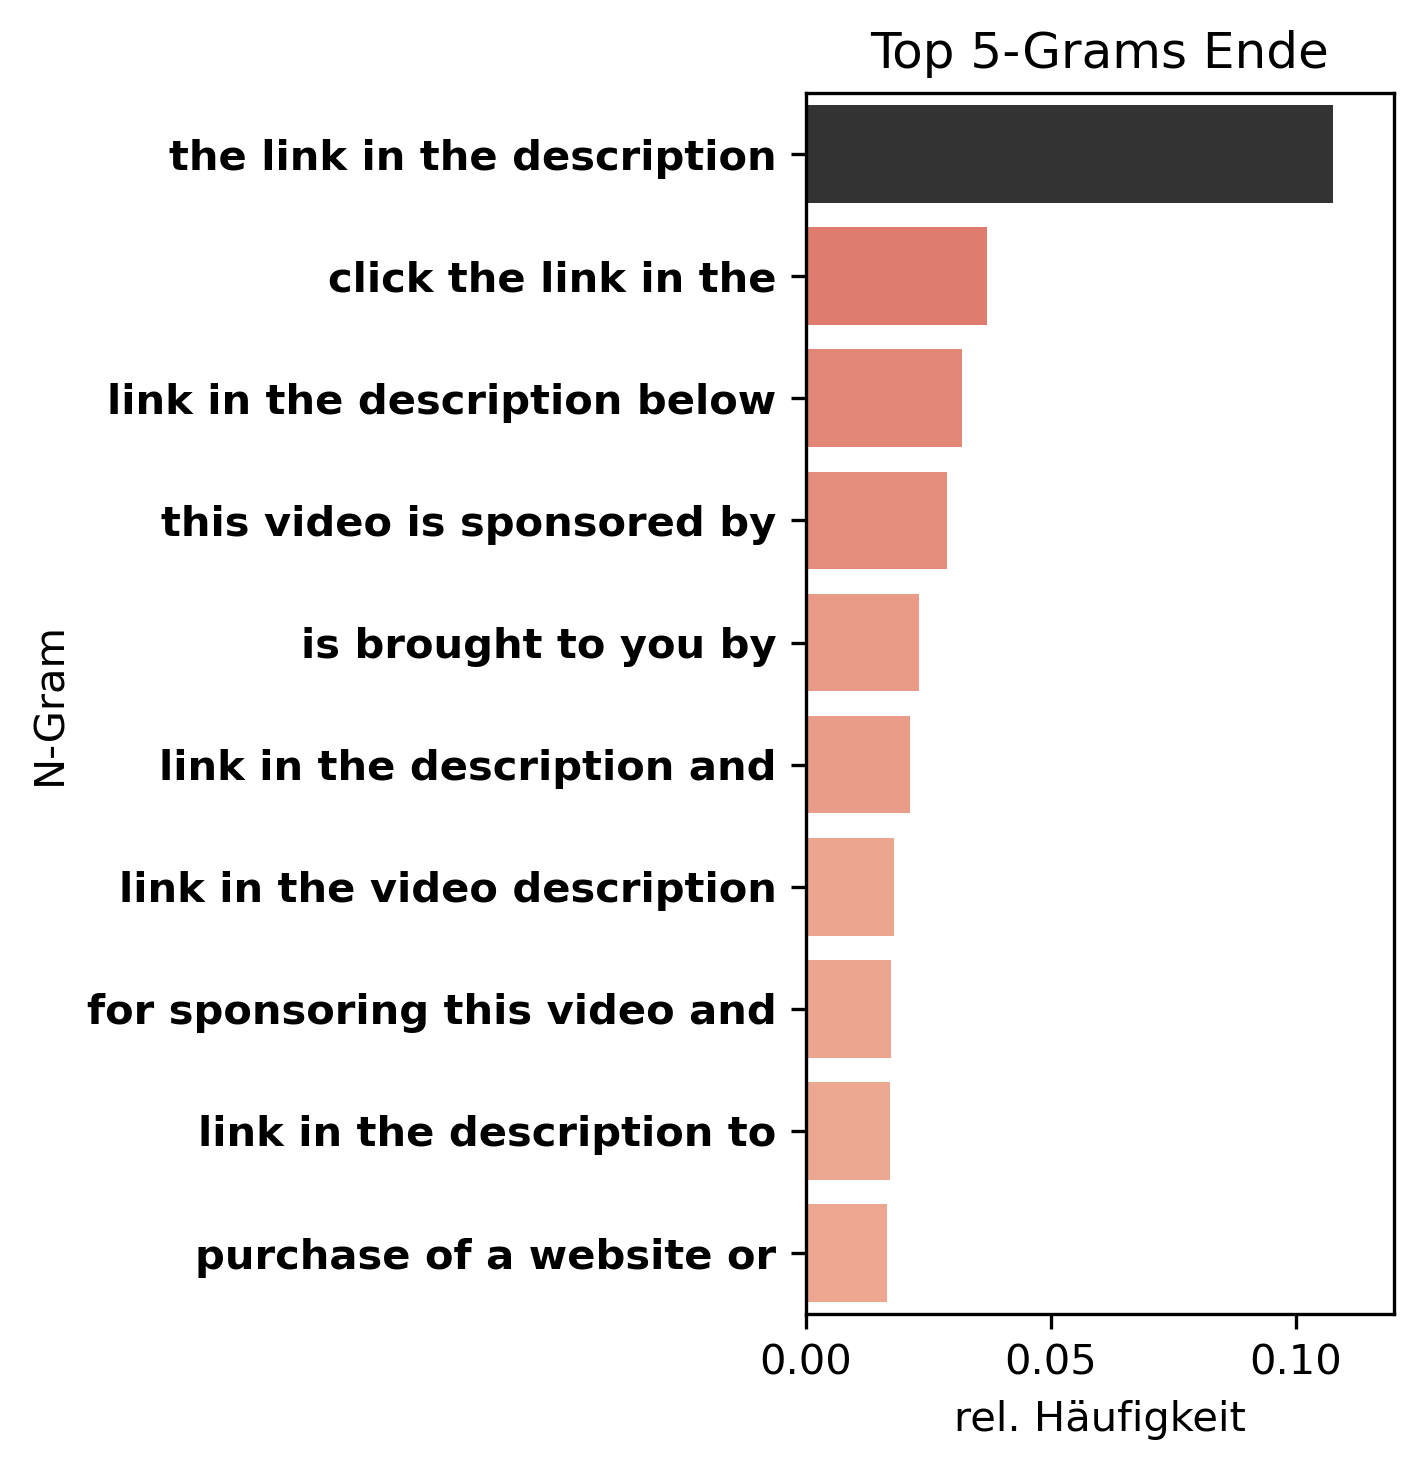

In [189]:
df = pd.DataFrame(ngrams, columns=["ngram", "count"])
df["ngram_str"] = df["ngram"].apply(lambda x: " ".join(x))

# Sortieren für Darstellung
df = df.sort_values("count", ascending=False)

# normalisieren
df["rel_freq"] = df["count"] / total

# Plot
plt.figure(figsize=(5, 5), dpi=300)
ax=sns.barplot(data=df, x="rel_freq", y="ngram_str", palette="Reds_d", hue="rel_freq", legend= False)
ax.set_yticklabels(ax.get_yticklabels(), weight='bold')
plt.xlabel("rel. Häufigkeit")
plt.xlim(0, 0.12)
plt.ylabel("N-Gram")
plt.title("Top 5-Grams Ende")
plt.tight_layout()
plt.show()